## **Part 1**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)


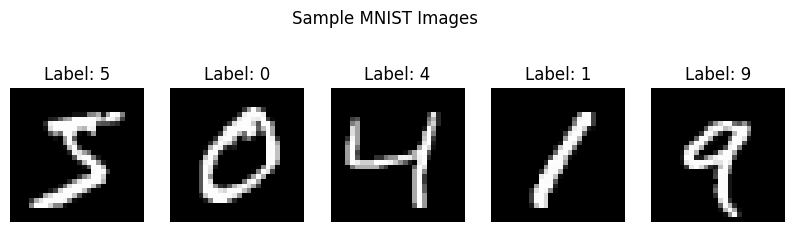

In [1]:
# Code for Loading and viewing MNIST data
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset; it's conveniently included in Keras
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Print shapes to understand the data dimensions
print("Training data shape:", X_train.shape) # (Num_samples, Height, Width)
print("Training labels shape:", y_train.shape) # (Num_samples,)

# Display first few images to visualize the data
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1); plt.imshow(X_train[i], cmap='gray'); plt.title(f"Label: {y_train[i]}"); plt.axis('off')
plt.suptitle("Sample MNIST Images"); plt.show()

# Set random seeds for numpy and tensorflow to ensure results are reproducible if code is run again
np.random.seed(42); tf.random.set_seed(42)

In [2]:
# Normalize pixel values by dividing by the maximum value (255.0)
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0
# Verify the new range
print(f"Pixel values normalized. Range: [{X_train_normalized.min()}, {X_train_normalized.max()}]")

Pixel values normalized. Range: [0.0, 1.0]


In [3]:
from tensorflow.keras import layers, models

# Define the ANN structure using the Sequential model
model = models.Sequential([
    # Input Layer / Flattening: Converts each 28x28 image into a 1D vector of 784 elements.
    # 'input_shape=(28, 28)' tells the layer the dimensions of each input sample.
    layers.Flatten(input_shape=(28, 28), name="Input_Flatten"),

    # Hidden Layer: A fully connected ('Dense') layer with 128 neurons.
    # 'activation='relu'' applies the ReLU activation function to the output of this layer.
    layers.Dense(128, activation='relu', name="Hidden_Layer_1"),

    # Output Layer: A Dense layer with 10 neurons (one for each digit class 0-9).
    # 'activation='softmax'' converts the outputs into probabilities for each class.
    layers.Dense(10, activation='softmax', name="Output_Layer")
], name="MNIST_ANN") # Naming the model is optional but helpful

print("\nModel Architecture Summary:")
# model.summary() provides a table showing layers, their output shapes, and the number of trainable parameters (weights + biases).
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Model Architecture Summary:


Model: "MNIST_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Flatten (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compile the model with optimizer, loss function, and metrics
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("\nModel compiled.")


Model compiled.


In [5]:
# Define training hyperparameters
epochs = 10 # Number of times to iterate over the entire training dataset
batch_size = 32 # Number of samples per gradient update

print(f"\nStarting model training for {epochs} epochs...")
# Train the model
history = model.fit(
    X_train_normalized, y_train, # Training data and labels
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2, # Use 20% of training data for validation during training
    verbose=1 # Show progress bar during training (0=silent, 1=bar, 2=line per epoch)
)
print("\nModel training completed.")


Starting model training for 10 epochs...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9210 - loss: 0.2782 - val_accuracy: 0.9563 - val_loss: 0.1519
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9634 - loss: 0.1239 - val_accuracy: 0.9647 - val_loss: 0.1140
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9749 - loss: 0.0845 - val_accuracy: 0.9682 - val_loss: 0.1038
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9819 - loss: 0.0619 - val_accuracy: 0.9703 - val_loss: 0.1020
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9873 - loss: 0.0461 - val_accuracy: 0.9703 - val_loss: 0.1011
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9909 - loss: 0.0347 - val_accuracy: 0.9709 - val_loss: 0.1021
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9935 - loss: 0.0259 - val_accuracy: 0.9740 - val_loss: 0.0985
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms

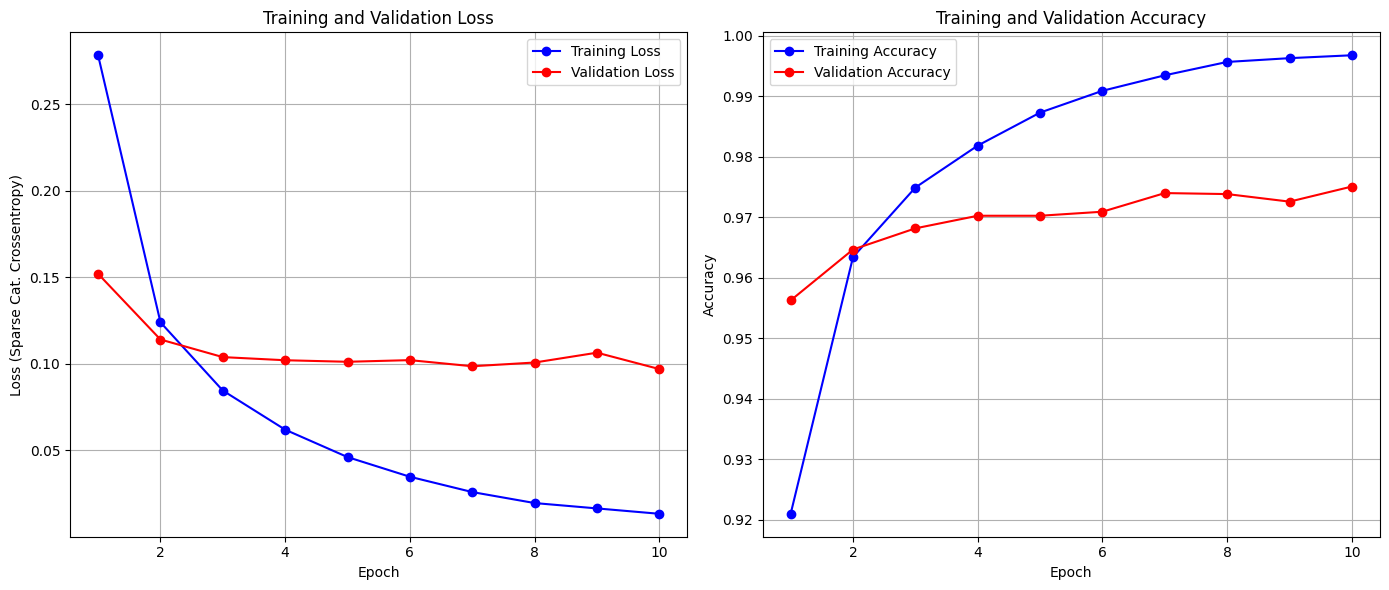

In [6]:
# Extract data from the History object returned by model.fit()
history_dict = history.history
train_loss = history_dict['loss']; val_loss = history_dict['val_loss']
train_accuracy = history_dict['accuracy']; val_accuracy = history_dict['val_accuracy']
# Create an array representing the epoch numbers for plotting
epochs_range = range(1, len(train_loss) + 1)

# Create subplots for loss and accuracy
plt.figure(figsize=(14, 6))
# Plot Loss curves
plt.subplot(1, 2, 1) # Position for the first plot
plt.plot(epochs_range, train_loss, 'bo-', label='Training Loss') # Blue line with dots
plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss') # Red line with dots
plt.title('Training and Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss (Sparse Cat. Crossentropy)'); plt.legend(); plt.grid(True)
# Plot Accuracy curves
plt.subplot(1, 2, 2) # Position for the second plot
plt.plot(epochs_range, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
# Adjust layout and display the plots
plt.tight_layout(); plt.show()

In [7]:
# Import the EarlyStopping callback from Keras
from tensorflow.keras.callbacks import EarlyStopping

# Define the Early Stopping callback instance
# 'monitor': the metric to watch (e.g., 'val_loss' or 'val_accuracy')
# 'patience': number of epochs with no improvement after which training will be stopped
# 'verbose=1': prints a message when stopping occurs
# 'restore_best_weights=True': ensures the final model weights are from the best epoch, not the last one
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Monitor validation loss for improvement
    patience=3,         # Stop if val_loss doesn't improve for 3 consecutive epochs
    verbose=1,
    restore_best_weights=True
)
print("Early Stopping callback defined.")

# --- Example Training with Early Stopping ---
# It's good practice to re-instantiate the model to start with fresh weights
# 1. Re-define the model architecture
model_es = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="MNIST_ANN_With_ES")

# 2. Re-compile the model
model_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\nNew model instance created and compiled for Early Stopping.")

# 3. Train with the EarlyStopping callback included in the 'callbacks' list
# Set a larger number of epochs, allowing Early Stopping to potentially finish sooner
epochs_max = 50
print(f"\nStarting model training with Early Stopping (max {epochs_max} epochs)...")

# Pass the callback to the fit method
history_es = model_es.fit(
    X_train_normalized, y_train,
    epochs=epochs_max,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_callback], # <-- Callback is included here
    verbose=1
)
print("\nModel training with Early Stopping completed.")

# (Visualization code for history_es, similar to 4.1, can be added to see the effect)

Early Stopping callback defined.

New model instance created and compiled for Early Stopping.

Starting model training with Early Stopping (max 50 epochs)...
Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9178 - loss: 0.2897 - val_accuracy: 0.9573 - val_loss: 0.1533
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9627 - loss: 0.1273 - val_accuracy: 0.9674 - val_loss: 0.1148
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9749 - loss: 0.0865 - val_accuracy: 0.9699 - val_loss: 0.1042
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9818 - loss: 0.0629 - val_accuracy: 0.9696 - val_loss: 0.1036
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9870 - loss: 0.0465 - val_accuracy: 0.9712 - val_loss: 0.1018
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9914 - loss: 0.0340 - val_accuracy: 0.9701 - val_loss: 0.1027
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accura

In [8]:
print("\n--- Evaluating Final Model on Test Set ---")
# Use the model trained with early stopping (model_es), as it likely performs better
# The .evaluate() method computes the loss and metrics on the provided data
final_loss, final_accuracy = model_es.evaluate(X_test_normalized, y_test, verbose=0) # verbose=0 hides progress bar
print(f"Final Test Accuracy (on unseen data): {final_accuracy:.4f}")
print(f"Final Test Loss (on unseen data): {final_loss:.4f}")


--- Evaluating Final Model on Test Set ---
Final Test Accuracy (on unseen data): 0.9724
Final Test Loss (on unseen data): 0.0921


------
## **Activity 1**

In [9]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
# Load MNIST dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = datasets.mnist.load_data()
print("--- MNIST Loaded ---")
print("MNIST Train shape:", X_train_mnist.shape) # (60000, 28, 28)

# Load CIFAR-10 dataset
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = datasets.cifar10.load_data()
print("\n--- CIFAR-10 Loaded ---")
print("CIFAR-10 Train shape:", X_train_cifar.shape) # (50000, 32, 32, 3)

# Define CIFAR-10 class names (index corresponds to label)
classes_cifar = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
print("CIFAR-10 Classes:", classes_cifar)

--- MNIST Loaded ---
MNIST Train shape: (60000, 28, 28)
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step

--- CIFAR-10 Loaded ---
CIFAR-10 Train shape: (50000, 32, 32, 3)
CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']



--- Sample MNIST Images ---


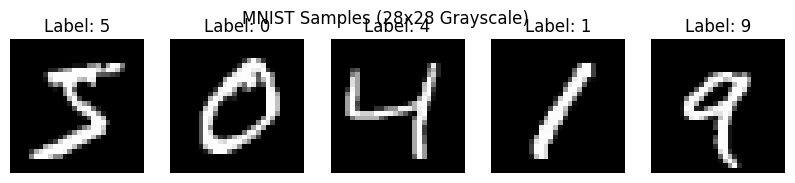


--- Sample CIFAR-10 Images ---


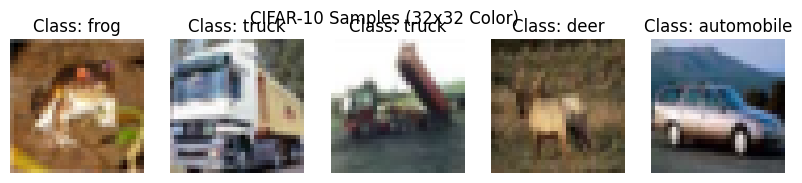


Notice the increased complexity in CIFAR-10 (color, varied objects, backgrounds).


In [11]:
print("\n--- Sample MNIST Images ---")
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1); plt.imshow(X_train_mnist[i], cmap='gray'); plt.title(f"Label: {y_train_mnist[i]}"); plt.axis('off')
plt.suptitle("MNIST Samples (28x28 Grayscale)")
plt.show()

print("\n--- Sample CIFAR-10 Images ---")
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1); plt.imshow(X_train_cifar[i]); plt.title(f"Class: {classes_cifar[y_train_cifar[i][0]]}"); plt.axis('off')
plt.suptitle("CIFAR-10 Samples (32x32 Color)")
plt.show()

print("\nNotice the increased complexity in CIFAR-10 (color, varied objects, backgrounds).")

In [12]:
print("\n--- Preprocessing Data ---")
# Normalize MNIST
X_train_mnist_norm = X_train_mnist / 255.0
X_test_mnist_norm = X_test_mnist / 255.0
print("MNIST normalization complete.")

# Normalize CIFAR-10
X_train_cifar_norm = X_train_cifar / 255.0
X_test_cifar_norm = X_test_cifar / 255.0
print("CIFAR-10 normalization complete.")

# Reshape CIFAR-10 labels (from (N, 1) to (N,))
y_train_cifar_flat = y_train_cifar.reshape(-1,)
y_test_cifar_flat = y_test_cifar.reshape(-1,)
print("CIFAR-10 labels reshaped:", y_train_cifar_flat.shape)


--- Preprocessing Data ---
MNIST normalization complete.
CIFAR-10 normalization complete.
CIFAR-10 labels reshaped: (50000,)


In [13]:
def build_ann_model(input_shape, num_classes, hidden_units=128):
  """Builds a simple sequential ANN model."""
  model = models.Sequential([
      # Flatten layer converts image matrix to 1D vector
      layers.Flatten(input_shape=input_shape),
      # Dense hidden layer (fully connected)
      layers.Dense(hidden_units, activation='relu'),
      # Dense output layer (one neuron per class)
      layers.Dense(num_classes, activation='softmax')
  ], name=f"Simple_ANN_{hidden_units}hidden")
  return model

# Example: Define input shapes (Height, Width, [Channels])
# Note: Flatten handles the multiplication internally based on input_shape
input_shape_mnist = (28, 28)   # Grayscale, no channel needed for Flatten input_shape
input_shape_cifar = (32, 32, 3) # Color image requires channel dimension

# Example: Define number of output classes
num_classes_mnist = 10
num_classes_cifar = 10

print("ANN builder function defined.")

ANN builder function defined.


In [14]:
print("\n--- ANN on MNIST (Baseline) ---")

# Build the MNIST ANN model
ann_mnist = build_ann_model(input_shape_mnist, num_classes_mnist)
ann_mnist.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
ann_mnist.summary()

print("\nTraining ANN on MNIST...")
# Train for a few epochs
history_mnist = ann_mnist.fit(X_train_mnist_norm, y_train_mnist,
                              epochs=5,
                              batch_size=32,
                              validation_split=0.1,
                              verbose=1) # Show progress

print("\nEvaluating ANN on MNIST Test Set...")
# --- Try to evaluate yourself first! ---
# What accuracy do you expect based on the summary/previous runs?
# Use: ann_mnist.evaluate(X_test_mnist_norm, y_test_mnist)


--- ANN on MNIST (Baseline) ---


Model: "Simple_ANN_128hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Training ANN on MNIST...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9217 - loss: 0.2752 - val_accuracy: 0.9628 - val_loss: 0.1310
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9635 - loss: 0.1226 - val_accuracy: 0.9690 - val_loss: 0.1031
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.0831 - val_accuracy: 0.9723 - val_loss: 0.0936
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9822 - loss: 0.0606 - val_accuracy: 0.9693 - val_loss: 0.0922
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9872 - loss: 0.0452 - val_accuracy: 0.9728 - val_loss: 0.0885

Evaluating ANN on MNIST Test Set...


In [15]:
# Evaluate the trained MNIST model
loss_mnist, accuracy_mnist = ann_mnist.evaluate(X_test_mnist_norm, y_test_mnist, verbose=0)
print(f"\nMNIST ANN Test Accuracy: {accuracy_mnist:.4f}")
print(f"MNIST ANN Test Loss: {loss_mnist:.4f}")
# Expected output: Accuracy should be high (typically ~97-98%)


MNIST ANN Test Accuracy: 0.9718
MNIST ANN Test Loss: 0.0896


In [16]:
print("\n--- ANN on CIFAR-10 (Main Experiment) ---")

# Build the CIFAR-10 ANN model using the SAME builder function
ann_cifar = build_ann_model(input_shape_cifar, num_classes_cifar)
ann_cifar.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy', # Still integer labels
                   metrics=['accuracy'])
ann_cifar.summary() # Note the much larger number of params in Flatten/Dense due to 32x32x3 input

print("\nTraining ANN on CIFAR-10...")
# Train for potentially more epochs, though performance might plateau quickly
history_cifar = ann_cifar.fit(X_train_cifar_norm, y_train_cifar_flat,
                              epochs=10, # Train a bit longer
                              batch_size=32,
                              validation_split=0.1,
                              verbose=1)

print("\nEvaluating ANN on CIFAR-10 Test Set...")
# --- Try to evaluate yourself first! ---
# What accuracy do you expect now? Compare it to the MNIST result.
# Use: ann_cifar.evaluate(X_test_cifar_norm, y_test_cifar_flat)


--- ANN on CIFAR-10 (Main Experiment) ---


Model: "Simple_ANN_128hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)


Training ANN on CIFAR-10...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3056 - loss: 1.9301 - val_accuracy: 0.3508 - val_loss: 1.8216
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3646 - loss: 1.7871 - val_accuracy: 0.3778 - val_loss: 1.7509
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3836 - loss: 1.7342 - val_accuracy: 0.3908 - val_loss: 1.7113
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3958 - loss: 1.7006 - val_accuracy: 0.3930 - val_loss: 1.6967
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4001 - loss: 1.6800 - val_accuracy: 0.3920 - val_loss: 1.6871
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4047 - loss: 1.6651 - val_accuracy: 0.3956 - val_loss: 1.6766
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4081 - loss: 1.6536 - val_accuracy: 0.4004 - val_loss: 1.6650
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accur

In [17]:
# Evaluate the trained CIFAR-10 model
loss_cifar, accuracy_cifar = ann_cifar.evaluate(X_test_cifar_norm, y_test_cifar_flat, verbose=0)
print(f"\nCIFAR-10 ANN Test Accuracy: {accuracy_cifar:.4f}")
print(f"CIFAR-10 ANN Test Loss: {loss_cifar:.4f}")
# Expected output: Accuracy will be significantly lower than MNIST (likely 40-50%)


CIFAR-10 ANN Test Accuracy: 0.4153
CIFAR-10 ANN Test Loss: 1.6271


In [18]:
print("\n--- Performance Comparison ---")

# Ensure you have run the evaluate code inside the <details> sections above
# If you encounter a NameError, go back and run the evaluate code in the hidden sections.
try:
    print(f"MNIST ANN Test Accuracy:      {accuracy_mnist:.4f}")
except NameError:
    print("MNIST accuracy variable ('accuracy_mnist') not found. Please run the evaluation in Step 6 <details>.")

try:
    print(f"CIFAR-10 ANN Test Accuracy:   {accuracy_cifar:.4f}")
except NameError:
    print("CIFAR-10 accuracy variable ('accuracy_cifar') not found. Please run the evaluation in Step 7 <details>.")

print("\n--- Discussion ---")
print("Observe the significant drop in accuracy when applying the same ANN to CIFAR-10.")
print("This highlights the limitations of simple ANNs for complex image tasks:")
print("1. Loss of Spatial Information: The Flatten layer discards the 2D/3D structure of pixels.")
print("2. Parameter Inefficiency: Dense layers connect every input pixel to every neuron, leading")
print("   to a very large number of parameters for images (compare model summaries).")
print("3. Lack of Translation Invariance: The ANN learns features based on absolute pixel positions,")
print("   making it sensitive to shifts or distortions in the object's location.")
print("\nThese challenges motivate the need for architectures specifically designed for spatial data.")


--- Performance Comparison ---
MNIST ANN Test Accuracy:      0.9718
CIFAR-10 ANN Test Accuracy:   0.4153

--- Discussion ---
Observe the significant drop in accuracy when applying the same ANN to CIFAR-10.
This highlights the limitations of simple ANNs for complex image tasks:
1. Loss of Spatial Information: The Flatten layer discards the 2D/3D structure of pixels.
2. Parameter Inefficiency: Dense layers connect every input pixel to every neuron, leading
   to a very large number of parameters for images (compare model summaries).
3. Lack of Translation Invariance: The ANN learns features based on absolute pixel positions,
   making it sensitive to shifts or distortions in the object's location.

These challenges motivate the need for architectures specifically designed for spatial data.


In [19]:
print("\n--- Conclusion ---")
print("This lab demonstrated that while ANNs can classify simple images like MNIST digits,")
print("their performance significantly degrades on more complex, real-world image datasets")
print("like CIFAR-10. This is primarily because they fail to leverage the spatial")
print("structure inherent in images.")
print("\n--- Next Steps ---")
print("In Part 2, we will explore Convolutional Neural Networks (CNNs), an architecture")
print("specifically developed to effectively process spatial data and achieve much")
print("better performance on image recognition tasks.")


--- Conclusion ---
This lab demonstrated that while ANNs can classify simple images like MNIST digits,
their performance significantly degrades on more complex, real-world image datasets
like CIFAR-10. This is primarily because they fail to leverage the spatial
structure inherent in images.

--- Next Steps ---
In Part 2, we will explore Convolutional Neural Networks (CNNs), an architecture
specifically developed to effectively process spatial data and achieve much
better performance on image recognition tasks.


----

## **Part 2**

Original Image Shape (Height, Width, Channels): (3, 3, 3)


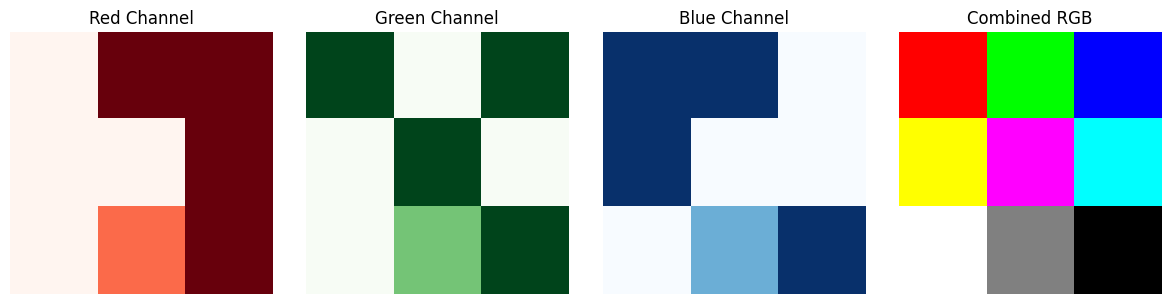


Red Channel Values:
 [[255   0   0]
 [255 255   0]
 [255 128   0]]

Green Channel Values:
 [[  0 255   0]
 [255   0 255]
 [255 128   0]]

Blue Channel Values:
 [[  0   0 255]
 [  0 255 255]
 [255 128   0]]


In [20]:
# Cell 1: Image Channels (RGB)
import numpy as np
import matplotlib.pyplot as plt

# Simulate a tiny 3x3 RGB image (values 0-255)
# Shape: (height, width, channels)
tiny_rgb_image = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255]],      # Row 1: Red, Green, Blue pixels
    [[255, 255, 0], [255, 0, 255], [0, 255, 255]], # Row 2: Yellow, Magenta, Cyan
    [[255, 255, 255], [128, 128, 128], [0, 0, 0]]  # Row 3: White, Gray, Black
], dtype=np.uint8)

print("Original Image Shape (Height, Width, Channels):", tiny_rgb_image.shape)

# Extract channels (Slicing the last dimension)
red_channel = tiny_rgb_image[:, :, 0]   # Index 0
green_channel = tiny_rgb_image[:, :, 1] # Index 1
blue_channel = tiny_rgb_image[:, :, 2]  # Index 2

# Display the channels and the combined image
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
axs[0].imshow(red_channel, cmap='Reds_r'); axs[0].set_title('Red Channel'); axs[0].axis('off')
axs[1].imshow(green_channel, cmap='Greens_r'); axs[1].set_title('Green Channel'); axs[1].axis('off')
axs[2].imshow(blue_channel, cmap='Blues_r'); axs[2].set_title('Blue Channel'); axs[2].axis('off')
axs[3].imshow(tiny_rgb_image); axs[3].set_title('Combined RGB'); axs[3].axis('off')
plt.tight_layout(); plt.show()

# Print the numerical values
print("\nRed Channel Values:\n", red_channel)
print("\nGreen Channel Values:\n", green_channel)
print("\nBlue Channel Values:\n", blue_channel)

Image loaded successfully.
Original Color Image Shape (H, W, C): (171, 256, 3)
Grayscale Image Shape (H, W): (171, 256)


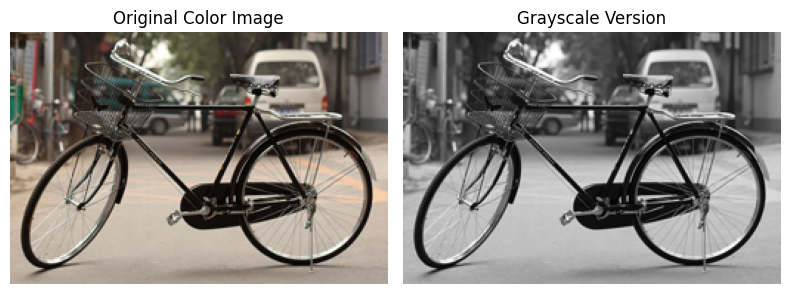

In [21]:
# Cell 1.5: Setup - Load and Prepare a Real Image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from scipy.signal import convolve2d

# --- Image Loading ---
try:
    # Example image URL (Wikimedia Commons - Bicycle) - Check license if using elsewhere!
    #image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/41/Left_side_of_Flying_Pigeon.jpg/640px-Left_side_of_Flying_Pigeon.jpg" # Option 1
    image_url = "https://raw.githubusercontent.com/ML-Course-2026/session7/refs/heads/main/material/img/640px-Left_side_of_Flying_Pigeon.jpg" # Option 2

    response = requests.get(image_url)
    response.raise_for_status() # Raise an exception for bad status codes
    img_pil = Image.open(BytesIO(response.content)).convert('RGB')

    # Resize for faster processing (optional, maintains aspect ratio)
    img_pil.thumbnail((256, 256)) # Max size 256x256

    # Convert to NumPy arrays
    img_rgb = np.array(img_pil).astype(np.float32) / 255.0 # Normalize to 0.0-1.0
    img_gray = np.array(img_pil.convert('L')).astype(np.float32) / 255.0 # Grayscale version, normalized

    print(f"Image loaded successfully.")
    print(f"Original Color Image Shape (H, W, C): {img_rgb.shape}")
    print(f"Grayscale Image Shape (H, W): {img_gray.shape}")

    # Display loaded images
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Color Image")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Grayscale Version")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Error loading image from URL: {e}")
    # Use placeholder arrays if image loading fails
    img_rgb = np.random.rand(100, 100, 3)
    img_gray = np.random.rand(100, 100)
    print("Using random noise array as fallback.")
except Exception as e:
     print(f"An error occurred: {e}")
     img_rgb = np.random.rand(100, 100, 3)
     img_gray = np.random.rand(100, 100)
     print("Using random noise array as fallback.")


# --- Define Filters (We'll reuse these) ---
# Vertical Edge Detection
filter_vertical = np.array([
    [ 1, 0, -1],
    [ 2, 0, -2],
    [ 1, 0, -1]
], dtype=np.float32)

# Horizontal Edge Detection
filter_horizontal = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

# Sharpen Filter
filter_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

Input Image Shape: (171, 256)
Filter Kernel Shape: (3, 3)
Feature Map Shape: (169, 254)


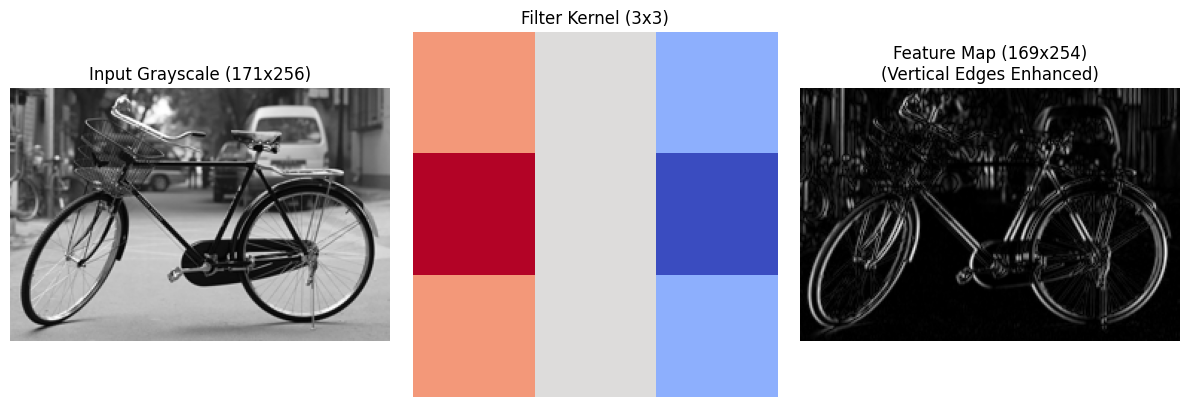

In [22]:
# Cell 2: How Features are Detected (Convolution with one filter on Real Image)

# Check if image loading was successful
if 'img_gray' not in globals():
    print("Grayscale image not loaded. Please run the setup cell first.")
else:
    # Use the grayscale image and the vertical edge filter
    input_image = img_gray
    filter_kernel = filter_vertical

    print("Input Image Shape:", input_image.shape)
    print("Filter Kernel Shape:", filter_kernel.shape)

    # Apply convolution (mode='valid' means no padding)
    # Flip kernel for strict convolution definition
    feature_map = convolve2d(input_image, np.flipud(np.fliplr(filter_kernel)), mode='valid')
    output_shape = feature_map.shape
    print(f"Feature Map Shape: {output_shape}")

    # Display
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(input_image, cmap='gray')
    plt.title(f'Input Grayscale ({input_image.shape[0]}x{input_image.shape[1]})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(filter_kernel, cmap='coolwarm')
    plt.title(f'Filter Kernel ({filter_kernel.shape[0]}x{filter_kernel.shape[1]})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    # Display absolute value or clip for better visualization of edges
    plt.imshow(np.abs(feature_map), cmap='gray')
    plt.title(f'Feature Map ({output_shape[0]}x{output_shape[1]})\n(Vertical Edges Enhanced)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Input Shape: (171, 256), Filter Shape: (3, 3)
Output Feature Map with Stride=3 Shape: (57x85)


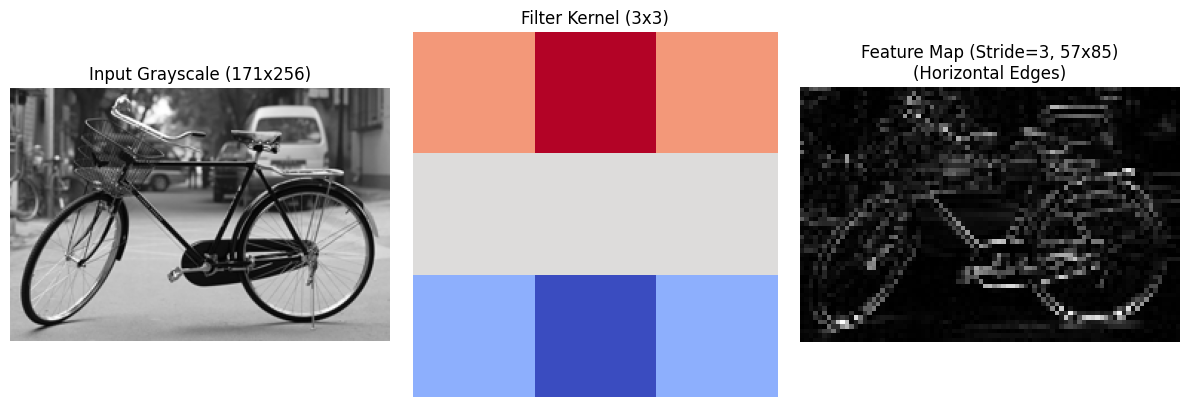

In [23]:
# Cell 3: Striding on Real Image

# Check if image loading was successful
if 'img_gray' not in globals():
    print("Grayscale image not loaded. Please run the setup cell first.")
else:
    # Use grayscale image and horizontal edge filter this time
    input_image = img_gray
    filter_kernel = filter_horizontal # Let's use the horizontal one here

    # Manual convolution calculation with stride = 3 (more noticeable reduction)
    stride = 3
    input_h, input_w = input_image.shape
    filter_h, filter_w = filter_kernel.shape
    # Calculate output dimensions
    output_h = int(np.floor((input_h - filter_h) / stride)) + 1
    output_w = int(np.floor((input_w - filter_w) / stride)) + 1
    feature_map_strided = np.zeros((output_h, output_w), dtype=np.float32)

    # Perform the convolution manually stepping by 'stride'
    for i in range(output_h):
        for j in range(output_w):
            start_row, start_col = i * stride, j * stride
            patch = input_image[start_row : start_row + filter_h, start_col : start_col + filter_w]
            # Ensure patch dimensions match filter if near edge with stride
            if patch.shape == filter_kernel.shape:
                 feature_map_strided[i, j] = np.sum(patch * filter_kernel)

    print(f"Input Shape: {input_image.shape}, Filter Shape: {filter_kernel.shape}")
    print(f"Output Feature Map with Stride={stride} Shape: ({output_h}x{output_w})")

    # Display
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(input_image, cmap='gray')
    plt.title(f'Input Grayscale ({input_image.shape[0]}x{input_image.shape[1]})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(filter_kernel, cmap='coolwarm')
    plt.title(f'Filter Kernel ({filter_kernel.shape[0]}x{filter_kernel.shape[1]})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(feature_map_strided), cmap='gray')
    plt.title(f'Feature Map (Stride={stride}, {output_h}x{output_w})\n(Horizontal Edges)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Original Input Shape: (171, 256)
Padded Image Shape: (173, 258)
Output Feature Map Shape after Padding: (171, 256)


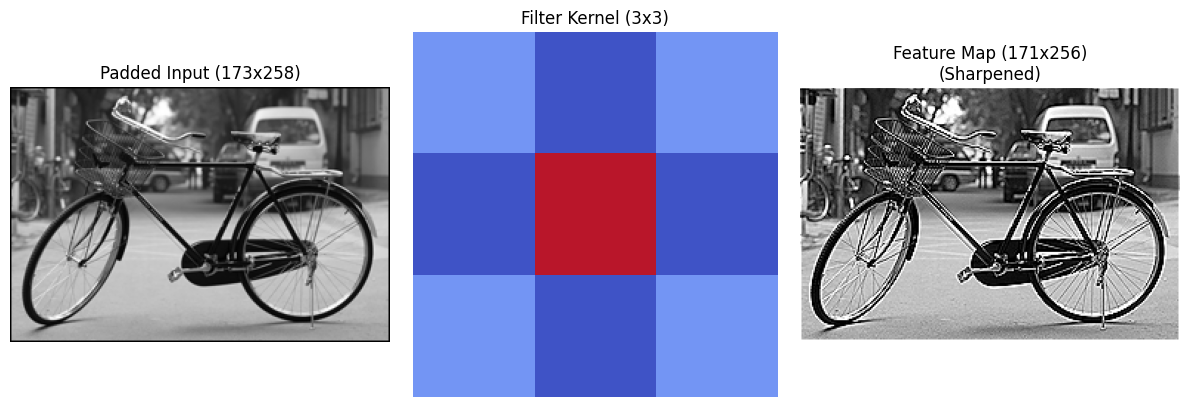

In [24]:
# Cell 4: Padding on Real Image

# Check if image loading was successful
if 'img_gray' not in globals():
    print("Grayscale image not loaded. Please run the setup cell first.")
else:
    # Use grayscale image and the sharpen filter
    input_image = img_gray
    filter_kernel = filter_sharpen

    # Add padding (p=1 layer of zeros)
    padding = 1
    padded_image = np.pad(input_image, pad_width=((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    print(f"Original Input Shape: {input_image.shape}")
    print(f"Padded Image Shape: {padded_image.shape}")

    # Apply convolution (stride=1) to the *padded* image using 'valid' mode
    feature_map_padded = convolve2d(padded_image, np.flipud(np.fliplr(filter_kernel)), mode='valid')
    output_shape = feature_map_padded.shape
    print(f"Output Feature Map Shape after Padding: {output_shape}")
    # Note: Output size = (Input_Padded - Filter + 1) should be same as Original Input

    # Display
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(padded_image, cmap='gray')
    plt.title(f'Padded Input ({padded_image.shape[0]}x{padded_image.shape[1]})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(filter_kernel, cmap='coolwarm', vmin=-1.1, vmax=5.1) # Adjust vmin/vmax for sharpen filter
    plt.title(f'Filter Kernel ({filter_kernel.shape[0]}x{filter_kernel.shape[1]})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    # Clip values to 0-1 range for display after sharpening
    plt.imshow(np.clip(feature_map_padded, 0, 1), cmap='gray')
    plt.title(f'Feature Map ({output_shape[0]}x{output_shape[1]})\n(Sharpened)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Input RGB Image Shape (H, W, C): (171, 256, 3)
Filter RGB Shape (H, W, C): (3, 3, 3)
Combined Feature Map Shape (Output is 2D): (169, 254)


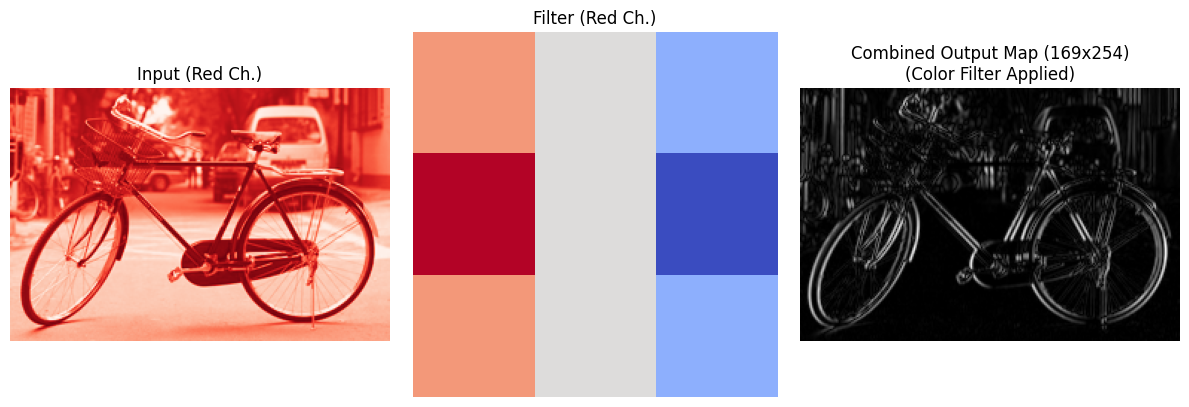

In [25]:
# Cell 5: How Convolutions are Applied over RGB Channels (Real Image)

# Check if image loading was successful
if 'img_rgb' not in globals():
    print("Color image not loaded. Please run the setup cell first.")
else:
    # Use the COLOR image (H, W, C)
    input_rgb = img_rgb

    # Create a 3x3x3 filter - e.g., detect vertical edges strongly in Red, ignore Green, weakly in Blue
    filter_rgb_single = np.zeros((3, 3, 3), dtype=np.float32)
    filter_rgb_single[:, :, 0] = filter_vertical # Strong vertical edge in Red (Ch 0)
    filter_rgb_single[:, :, 1] = 0               # Ignore Green (Ch 1)
    filter_rgb_single[:, :, 2] = filter_vertical * 0.5 # Weak vertical edge in Blue (Ch 2)

    print("Input RGB Image Shape (H, W, C):", input_rgb.shape)
    print("Filter RGB Shape (H, W, C):", filter_rgb_single.shape)

    # Manual convolution (stride=1, no padding)
    stride = 1
    input_h, input_w, input_c = input_rgb.shape
    filter_h, filter_w, filter_c = filter_rgb_single.shape
    output_h = ((input_h - filter_h) // stride) + 1
    output_w = ((input_w - filter_w) // stride) + 1
    feature_map_rgb_combined = np.zeros((output_h, output_w), dtype=np.float32)

    for i in range(output_h):
        for j in range(output_w):
            patch = input_rgb[i*stride : i*stride + filter_h, j*stride : j*stride + filter_w, :]
            if patch.shape == filter_rgb_single.shape:
                activation = np.sum(patch * filter_rgb_single) # Sum over all H*W*C elements
                feature_map_rgb_combined[i, j] = activation

    print(f"Combined Feature Map Shape (Output is 2D): {feature_map_rgb_combined.shape}")

    # Display (Input R channel, Filter R channel, combined output map)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(input_rgb[:,:,0], cmap='Reds_r') # Show R channel of input
    plt.title('Input (Red Ch.)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(filter_rgb_single[:,:,0], cmap='coolwarm') # Show R channel of filter
    plt.title('Filter (Red Ch.)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(feature_map_rgb_combined), cmap='gray') # Show absolute value
    plt.title(f'Combined Output Map ({output_h}x{output_w})\n(Color Filter Applied)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Input RGB Image Shape (H, W, C): (171, 256, 3)
Number of Filters: 2
Stacked Output Feature Maps Shape (H, W, NumFilters): (169, 254, 2)


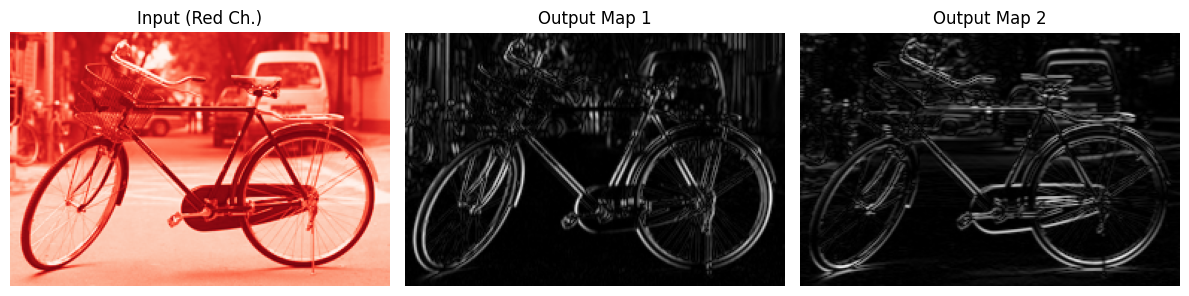

In [26]:
# Cell 6: How Convolutions are Applied with More Than One Filter (Real Image)

# Check if image loading was successful
if 'img_rgb' not in globals():
    print("Color image not loaded. Please run the setup cell first.")
else:
    # Use the COLOR image
    input_rgb = img_rgb

    # Define TWO different 3x3x3 filters
    # Filter 1: Vertical Edge detector (strong on Red, weak on Blue)
    filter_1_rgb = np.zeros((3, 3, 3), dtype=np.float32)
    filter_1_rgb[:, :, 0] = filter_vertical * 1.0
    filter_1_rgb[:, :, 2] = filter_vertical * 0.5

    # Filter 2: Horizontal Edge detector (strong on Green)
    filter_2_rgb = np.zeros((3, 3, 3), dtype=np.float32)
    filter_2_rgb[:, :, 1] = filter_horizontal * 1.0

    filters_list = [filter_1_rgb, filter_2_rgb]
    num_filters = len(filters_list)

    print("Input RGB Image Shape (H, W, C):", input_rgb.shape)
    print("Number of Filters:", num_filters)

    # Apply each filter (stride=1, no padding)
    stride = 1
    input_h, input_w, input_c = input_rgb.shape
    filter_h, filter_w, filter_c = filters_list[0].shape
    output_h = ((input_h - filter_h) // stride) + 1
    output_w = ((input_w - filter_w) // stride) + 1
    # Output will have shape (H, W, NumFilters)
    output_feature_maps = np.zeros((output_h, output_w, num_filters), dtype=np.float32)

    for f_idx, current_filter in enumerate(filters_list):
        for i in range(output_h):
            for j in range(output_w):
                patch = input_rgb[i*stride : i*stride + filter_h, j*stride : j*stride + filter_w, :]
                if patch.shape == current_filter.shape:
                     activation = np.sum(patch * current_filter)
                     output_feature_maps[i, j, f_idx] = activation

    print(f"Stacked Output Feature Maps Shape (H, W, NumFilters): {output_feature_maps.shape}")

    # Display the input R channel and the two resulting feature maps
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 1 + num_filters, 1)
    plt.imshow(input_rgb[:,:,0], cmap='Reds_r') # Show R channel of input
    plt.title('Input (Red Ch.)')
    plt.axis('off')

    # Display each feature map
    for f_idx in range(num_filters):
        plt.subplot(1, 1 + num_filters, f_idx + 2)
        plt.imshow(np.abs(output_feature_maps[:, :, f_idx]), cmap='gray')
        plt.title(f'Output Map {f_idx+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Original Feature Map (4x4):
 [[12. 20. 30.  0.]
 [ 8. 18.  2. 25.]
 [15.  5. 22. 19.]
 [21. 10.  9. 31.]]

Max Pooled Map (2x2):
 [[20. 30.]
 [21. 31.]]


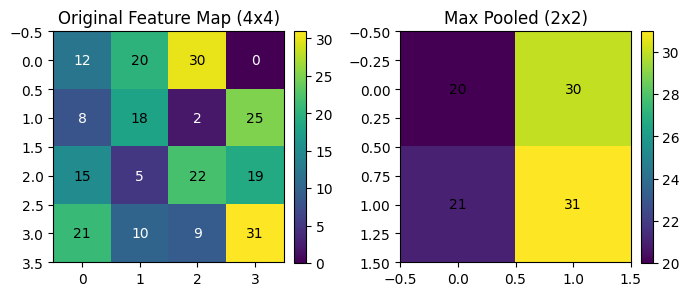

In [27]:
# Cell 7: Pooling Layers (Max Pooling)
# Example 4x4 feature map
feature_map = np.array([
    [12, 20, 30,  0], [ 8, 18,  2, 25], [15,  5, 22, 19], [21, 10,  9, 31]
], dtype=np.float32)
print("Original Feature Map (4x4):\n", feature_map)

# Apply Max Pooling (2x2 window, stride=2)
pool_size = 2; stride = 2
map_h, map_w = feature_map.shape
output_h = int(np.floor((map_h - pool_size) / stride)) + 1 # (4-2)/2 + 1 = 2
output_w = int(np.floor((map_w - pool_size) / stride)) + 1 # (4-2)/2 + 1 = 2
pooled_map = np.zeros((output_h, output_w), dtype=np.float32)

for i in range(output_h):
    for j in range(output_w):
        patch = feature_map[i*stride : i*stride + pool_size, j*stride : j*stride + pool_size]
        pooled_map[i, j] = np.max(patch)

print(f"\nMax Pooled Map ({output_h}x{output_w}):\n", pooled_map)

# Display
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
def plot_matrix_pooling(ax, data, title): # Helper to show values
    im = ax.imshow(data, cmap='viridis'); ax.set_title(title)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r, c]:.0f}", ha='center', va='center', color='white' if data[r,c] < 15 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_matrix_pooling(axs[0], feature_map, 'Original Feature Map (4x4)')
plot_matrix_pooling(axs[1], pooled_map, f'Max Pooled ({output_h}x{output_w})')
plt.tight_layout(); plt.show()

Input to Flattening (Pooled Feature Maps):
Shape (H, W, C): (2, 2, 2)
Data:
 [[[40. 55.]
  [75. 65.]]

 [[90. 85.]
  [95. 70.]]]

Flattened Vector:
Shape: (8,)
Data: [40. 55. 75. 65. 90. 85. 95. 70.]


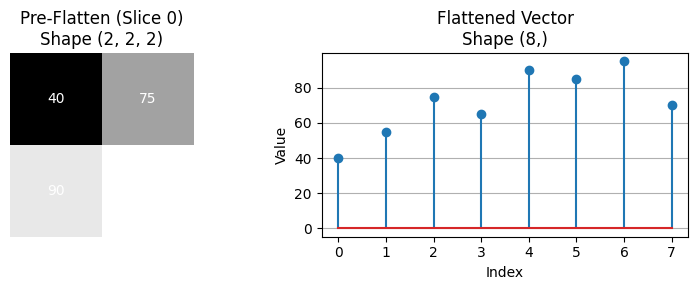

In [28]:
# Cell 8: Flattening
# Example 2x2x2 volume (e.g., output from pooling 2 feature maps)
pooled_output_multi_filter = np.array([
    [[40, 55], [75, 65]], # H=0, W=0, C=0,1 | H=0, W=1, C=0,1
    [[90, 85], [95, 70]]  # H=1, W=0, C=0,1 | H=1, W=1, C=0,1
], dtype=np.float32) # Shape is (H, W, C) = (2, 2, 2)

print("Input to Flattening (Pooled Feature Maps):")
print("Shape (H, W, C):", pooled_output_multi_filter.shape)
print("Data:\n", pooled_output_multi_filter)

# Flatten the 3D array into a 1D vector (C-style order: last axis changes fastest)
flattened_vector = pooled_output_multi_filter.flatten(order='C')

print("\nFlattened Vector:")
print("Shape:", flattened_vector.shape) # (2*2*2,) = (8,)
print("Data:", flattened_vector) # Order: (0,0,0), (0,0,1), (0,1,0), (0,1,1), (1,0,0), ...

# Visualization
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1); plt.imshow(pooled_output_multi_filter[:, :, 0], cmap='gray'); plt.title(f'Pre-Flatten (Slice 0)\nShape {pooled_output_multi_filter.shape}'); plt.axis('off')
for r in range(2):
    for c in range(2): plt.text(c, r, f'{pooled_output_multi_filter[r, c, 0]:.0f}', ha='center', va='center', color='white')
plt.subplot(1, 2, 2); plt.stem(flattened_vector); plt.title(f'Flattened Vector\nShape {flattened_vector.shape}')
plt.xticks(np.arange(len(flattened_vector))); plt.grid(True, axis='y'); plt.xlabel('Index'); plt.ylabel('Value')
plt.tight_layout(); plt.show()

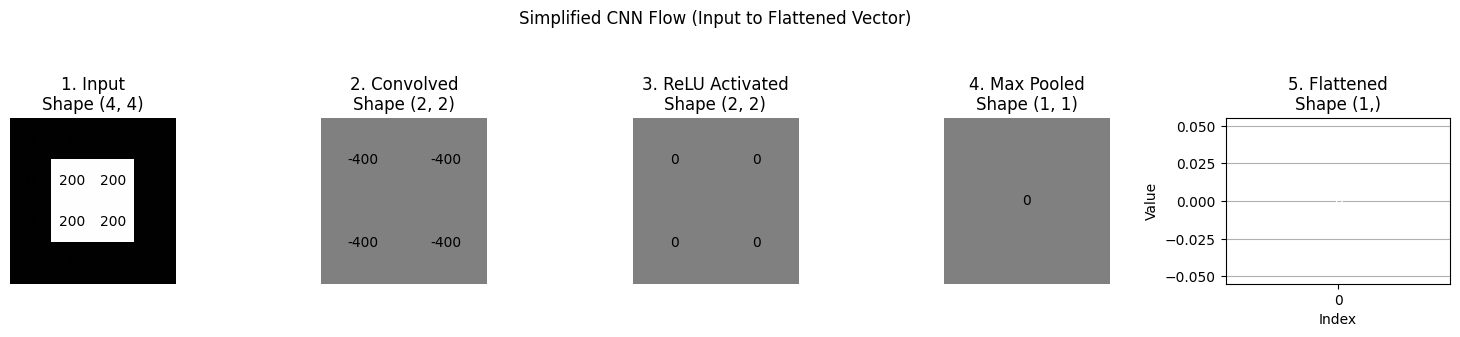


Final flattened vector (ready for Dense layers): [0.]


In [29]:
# Cell 9: Full Connection (Simplified Conceptual Flow - Steps before Dense layers)
# --- Simulate Steps on a Tiny Example ---
input_simple = np.array([[0, 0, 0, 0],[0, 200, 200, 0],[0, 200, 200, 0],[0, 0, 0, 0]], dtype=np.float32) # 1. Input
kernel_simple = np.array([[0, 1, 0],[1, -4, 1],[0, 1, 0]], dtype=np.float32) # Laplacian filter
convolved_simple = convolve2d(input_simple, np.flipud(np.fliplr(kernel_simple)), mode='valid') # 2. Convolved (2x2)
activated_simple = np.maximum(0, convolved_simple) # 3. ReLU Activated (2x2)
pooled_simple = np.array([[np.max(activated_simple)]]) # 4. Max Pooled (1x1) - Simplified pooling for 2x2 input
flattened_simple = pooled_simple.flatten() # 5. Flattened (vector size 1)

# --- Display Conceptual Flow ---
fig, axs = plt.subplots(1, 5, figsize=(15, 3.5))
def plot_matrix_fc(ax, data, title): # Helper to show values
    im = ax.imshow(data, cmap='gray', vmin=np.min(data)-1, vmax=np.max(data)+1)
    ax.set_title(f'{title}\nShape {data.shape}'); ax.axis('off')
    for r in range(data.shape[0]):
        for c in range(data.shape[1]): ax.text(c, r, f'{data[r, c]:.0f}', ha='center', va='center', color='white' if np.mean(data) > 100 else 'black') # Basic color logic

plot_matrix_fc(axs[0], input_simple, '1. Input')
plot_matrix_fc(axs[1], convolved_simple, '2. Convolved')
plot_matrix_fc(axs[2], activated_simple, '3. ReLU Activated')
plot_matrix_fc(axs[3], pooled_simple, '4. Max Pooled')
axs[4].bar(np.arange(len(flattened_simple)), flattened_simple); axs[4].set_title(f'5. Flattened\nShape {flattened_simple.shape}')
axs[4].set_xticks(np.arange(len(flattened_simple))); axs[4].grid(True, axis='y'); axs[4].set_xlabel('Index'); axs[4].set_ylabel('Value')
if len(flattened_simple) > 0: axs[4].text(0, flattened_simple[0]/2, f'{flattened_simple[0]:.0f}', ha='center', va='center', color='white')
plt.suptitle('Simplified CNN Flow (Input to Flattened Vector)')
plt.tight_layout(rect=[0, 0.03, 1, 0.93]); plt.show()

print(f"\nFinal flattened vector (ready for Dense layers): {flattened_simple}")

In [30]:
# Import necessary Keras components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    """Creates a simple CNN model using Keras."""
    model = Sequential([
        # First Convolutional Layer: Extracts initial features
        # 32 filters, each 3x3. 'relu' activation introduces non-linearity.
        # input_shape specifies (height, width, channels) for the first layer.
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),

        # First Pooling Layer: Reduces dimensions (downsamples)
        MaxPooling2D((2, 2)),

        # Second Convolutional Layer: Extracts more complex features
        # 64 filters, each 3x3.
        Conv2D(64, (3, 3), activation='relu'),

        # Second Pooling Layer: Further reduces dimensions
        MaxPooling2D((2, 2)),

        # Flatten Layer: Converts 3D feature maps to a 1D vector
        Flatten(),

        # First Dense (Fully Connected) Layer: Learns combinations of features
        # 64 neurons, 'relu' activation.
        Dense(64, activation='relu'), # Adjusted to a more typical small example

        # Output Dense Layer: Produces final classification probabilities
        # 'num_classes' neurons (e.g., 10 for digits 0-9).
        # 'softmax' activation ensures outputs sum to 1 (probabilities).
        Dense(num_classes, activation='softmax')
    ])

    # Compile the model: Configure optimizer, loss function, and metrics for training
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy', # Use for multi-class classification with one-hot encoded labels
                  metrics=['accuracy'])
    return model

# Example usage: Create the model and print summary
# Assuming input images are 32x32 RGB and there are 10 classes
example_model = create_cnn_model(input_shape=(32, 32, 3), num_classes=10)
example_model.summary() # Prints a table showing layers, output shapes, and parameters

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

----
## **activity 2**

In [31]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

--- Dataset Shapes ---
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

--- Sample Images ---


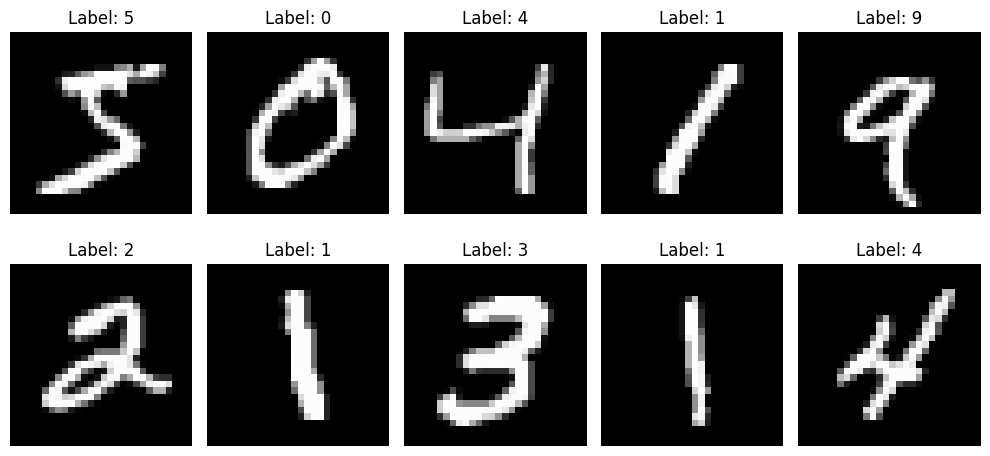

In [32]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("--- Dataset Shapes ---")
print("Training images shape:", X_train.shape) # Output: (60000, 28, 28) -> 60k images, 28x28 pixels each
print("Training labels shape:", y_train.shape) # Output: (60000,) -> 60k labels
print("Test images shape:", X_test.shape)     # Output: (10000, 28, 28)
print("Test labels shape:", y_test.shape)     # Output: (10000,)

print("\n--- Sample Images ---")
plt.figure(figsize=(10, 5))
for i in range(10): # Display first 10 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray') # Display in grayscale
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

In [33]:
print("\n--- Preprocessing ---")
# Check label shapes before potentially reshaping (optional, usually okay for MNIST)
print("Original y_train shape:", y_train.shape)
y_train = y_train.reshape(-1,) # Ensure y_train is a 1D array
y_test = y_test.reshape(-1,)   # Ensure y_test is a 1D array
print("Reshaped y_train shape:", y_train.shape)

# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Data normalized.")


--- Preprocessing ---
Original y_train shape: (60000,)
Reshaped y_train shape: (60000,)
Data normalized.


In [34]:
print("\n--- Building ANN Model ---")
ann = models.Sequential([
    # Flatten the 28x28 image into a 1D vector of 784 pixels
    layers.Flatten(input_shape=(28, 28)),

    # Dense hidden layer with 128 neurons and ReLU activation
    layers.Dense(128, activation='relu'),

    # Output layer with 10 neurons (one for each digit 0-9)
    # Softmax activation outputs probabilities for each class
    layers.Dense(10, activation='softmax')
])

# Compile the model: configure optimizer, loss function, and metrics
ann.compile(optimizer='adam',                     # Adam optimizer is generally a good default
            loss='sparse_categorical_crossentropy', # Use for integer labels (0, 1, ... 9)
            metrics=['accuracy'])                 # Track accuracy during training

ann.summary() # Print model architecture

print("\n--- Training ANN Model ---")
# Train the model for 5 epochs (passes through the entire training dataset)
history_ann = ann.fit(X_train, y_train, epochs=5, validation_split=0.1) # Use 10% of training data for validation


--- Building ANN Model ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Training ANN Model ---
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9219 - loss: 0.2721 - val_accuracy: 0.9663 - val_loss: 0.1213
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9647 - loss: 0.1195 - val_accuracy: 0.9715 - val_loss: 0.0949
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9766 - loss: 0.0806 - val_accuracy: 0.9740 - val_loss: 0.0828
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9830 - loss: 0.0587 - val_accuracy: 0.9770 - val_loss: 0.0772
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9880 - loss: 0.0430 - val_accuracy: 0.9770 - val_loss: 0.0786



--- Evaluating ANN Model ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9741 - loss: 0.0854
ANN Test Accuracy: 0.9741
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report (ANN):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.94      0.99      0.96      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.96      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000


Confusion Matrix (ANN):


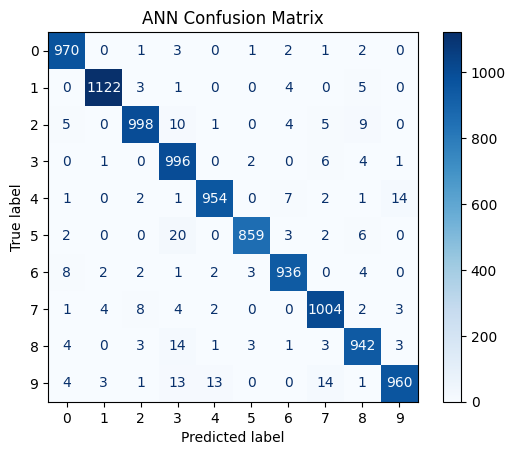

In [35]:
print("\n--- Evaluating ANN Model ---")
loss_ann, accuracy_ann = ann.evaluate(X_test, y_test)
print(f"ANN Test Accuracy: {accuracy_ann:.4f}")

# Make predictions on the test set
y_pred_ann_prob = ann.predict(X_test)
# Convert probabilities to predicted class labels (index of the max probability)
y_pred_ann_classes = np.argmax(y_pred_ann_prob, axis=1)

# Print Classification Report
print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann_classes))

# Display Confusion Matrix
print("\nConfusion Matrix (ANN):")
cm_ann = confusion_matrix(y_test, y_pred_ann_classes)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann)
disp_ann.plot(cmap=plt.cm.Blues)
plt.title("ANN Confusion Matrix")
plt.show()

In [36]:
print("\n--- Building CNN Model ---")
cnn = models.Sequential([
    # First Convolutional Layer: Learns 32 basic features (like edges, corners)
    # kernel_size=(3,3): Uses a 3x3 filter window
    # activation='relu': Standard activation for non-linearity
    # input_shape=(28, 28, 1): MNIST image dimensions (Height, Width, Channels=1 for grayscale)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # Pooling Layer: Reduces size by half (2x2 window), keeps strongest activations
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer: Learns 64 more complex features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Another pooling layer

    # Flatten Layer: Converts the 2D feature maps into a 1D vector
    layers.Flatten(),

    # Dense Layer: A fully connected layer for combining features
    layers.Dense(64, activation='relu'),

    # Output Layer: 10 neurons (one for each digit 0-9), softmax for probabilities
    layers.Dense(10, activation='softmax')
])

# Compile the CNN model
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary() # Print CNN architecture

# Reshape input data for CNN (add channel dimension)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
print("\nReshaped training data for CNN:", X_train_cnn.shape)

print("\n--- Training CNN Model ---")
# Train the CNN model (fewer epochs often needed than ANN for good performance)
history_cnn = cnn.fit(X_train_cnn, y_train, epochs=3, validation_split=0.1)


--- Building CNN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Reshaped training data for CNN: (60000, 28, 28, 1)

--- Training CNN Model ---
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9556 - loss: 0.1456 - val_accuracy: 0.9857 - val_loss: 0.0515
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9844 - loss: 0.0493 - val_accuracy: 0.9853 - val_loss: 0.0488
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9899 - loss: 0.0323 - val_accuracy: 0.9850 - val_loss: 0.0559


In [37]:
print("\n--- Evaluating CNN Model ---")
loss_cnn, accuracy_cnn = cnn.evaluate(X_test_cnn, y_test)
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")


--- Evaluating CNN Model ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9841 - loss: 0.0455
CNN Test Accuracy: 0.9841



--- Model Comparison ---
ANN Test Accuracy: 0.9741
CNN Test Accuracy: 0.9841

Notice the difference in accuracy. CNNs typically excel at image tasks because
convolutional layers effectively capture spatial hierarchies and features.
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Visualizing CNN Predictions (Examples) ---


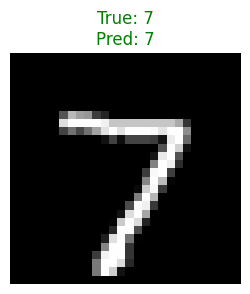

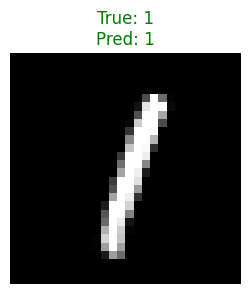

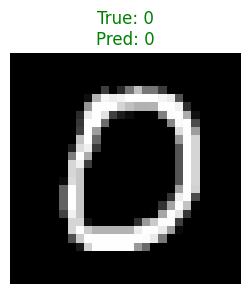


Confusion Matrix (CNN):


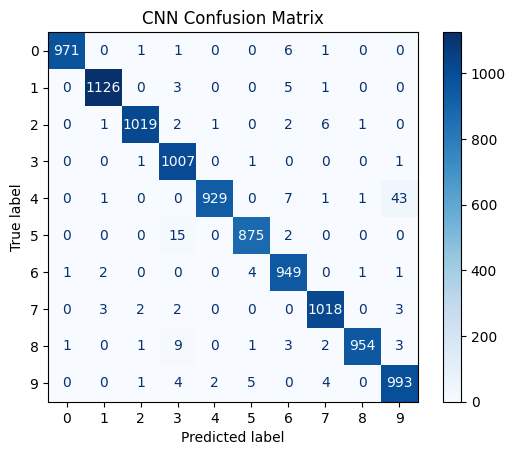

In [38]:
print("\n--- Model Comparison ---")
print(f"ANN Test Accuracy: {accuracy_ann:.4f}")
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")
# Prompt for reflection:
print("\nNotice the difference in accuracy. CNNs typically excel at image tasks because")
print("convolutional layers effectively capture spatial hierarchies and features.")

# Make predictions with the CNN
y_pred_cnn_prob = cnn.predict(X_test_cnn)
y_pred_cnn_classes = np.argmax(y_pred_cnn_prob, axis=1)

# Define the enhanced plotting function
def plot_sample_with_pred(X, y_true, y_pred_classes, index, class_names=None):
    plt.figure(figsize=(3, 3))
    plt.imshow(X[index].reshape(28, 28), cmap='gray') # Reshape back for plotting if needed
    true_label = y_true[index]
    pred_label = y_pred_classes[index]
    title_str = f"True: {true_label}\nPred: {pred_label}"
    if class_names: # If class names list is provided
         title_str = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    color = "green" if true_label == pred_label else "red"
    plt.title(title_str, color=color)
    plt.axis('off')
    plt.show()

print("\n--- Visualizing CNN Predictions (Examples) ---")
# Show prediction for a few test samples
plot_sample_with_pred(X_test, y_test, y_pred_cnn_classes, 0) # Index 0
plot_sample_with_pred(X_test, y_test, y_pred_cnn_classes, 5) # Index 5
plot_sample_with_pred(X_test, y_test, y_pred_cnn_classes, 10) # Index 10

# Display CNN Confusion Matrix
print("\nConfusion Matrix (CNN):")
cm_cnn = confusion_matrix(y_test, y_pred_cnn_classes)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
disp_cnn.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.show()

In [39]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

--- CIFAR-10 Dataset Shapes ---
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

--- CIFAR-10 Sample Images ---


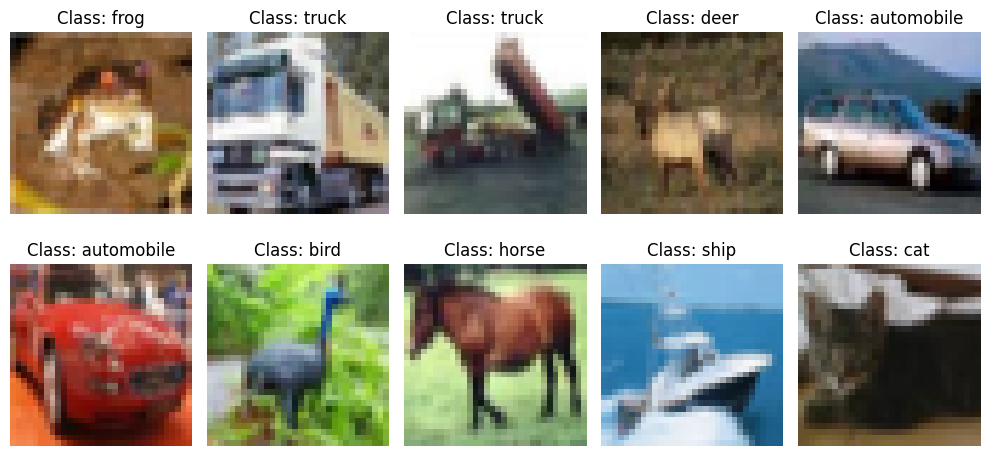

In [40]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = datasets.cifar10.load_data()

print("--- CIFAR-10 Dataset Shapes ---")
print("Training images shape:", X_train_cifar.shape) # Output: (50000, 32, 32, 3)
print("Training labels shape:", y_train_cifar.shape) # Output: (50000, 1) -> Note the extra dimension
print("Test images shape:", X_test_cifar.shape)     # Output: (10000, 32, 32, 3)
print("Test labels shape:", y_test_cifar.shape)     # Output: (10000, 1)

# Define class names for CIFAR-10
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

print("\n--- CIFAR-10 Sample Images ---")
plt.figure(figsize=(10, 5))
for i in range(10): # Display first 10 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_cifar[i])
    # Use y_train_cifar[i][0] because labels are shape (N, 1)
    plt.title(f"Class: {classes[y_train_cifar[i][0]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [41]:
print("\n--- Preprocessing CIFAR-10 ---")
# Reshape labels to 1D arrays
y_train_cifar = y_train_cifar.reshape(-1,)
y_test_cifar = y_test_cifar.reshape(-1,)
print("Reshaped y_train_cifar shape:", y_train_cifar.shape)

# Normalize pixel values
X_train_cifar = X_train_cifar / 255.0
X_test_cifar = X_test_cifar / 255.0
print("CIFAR-10 data normalized.")


--- Preprocessing CIFAR-10 ---
Reshaped y_train_cifar shape: (50000,)
CIFAR-10 data normalized.


In [42]:
print("\n--- Building ANN Model (CIFAR-10) ---")
ann_cifar = models.Sequential([
    # Flatten the 32x32x3 image into a 1D vector (3072 elements)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Larger Dense hidden layers (ANNs need many parameters for images)
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),

    # Output layer with 10 neurons (one for each CIFAR class)
    layers.Dense(10, activation='softmax')
])

# Compile the model (using Adam for consistency)
ann_cifar.compile(optimizer='adam', # Changed from SGD to Adam
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_cifar.summary()

print("\n--- Training ANN Model (CIFAR-10) ---")
# Train for a few epochs (ANN performance plateaus quickly here)
history_ann_cifar = ann_cifar.fit(X_train_cifar, y_train_cifar, epochs=5, validation_split=0.1)


--- Building ANN Model (CIFAR-10) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3000)           │     9,219,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,230,010 (46.65 MB)

 Trainable params: 12,230,010 (46.65 MB)

 Non-trainable params: 0 (0.00 B)


--- Training ANN Model (CIFAR-10) ---
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.3251 - loss: 1.9053 - val_accuracy: 0.3650 - val_loss: 1.7605
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - accuracy: 0.3994 - loss: 1.6759 - val_accuracy: 0.4116 - val_loss: 1.6209
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4320 - loss: 1.5897 - val_accuracy: 0.4246 - val_loss: 1.5903
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4493 - loss: 1.5371 - val_accuracy: 0.4328 - val_loss: 1.5927
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4628 - loss: 1.4981 - val_accuracy: 0.4510 - val_loss: 1.5432



--- Evaluating ANN Model (CIFAR-10) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4614 - loss: 1.5212
CIFAR-10 ANN Test Accuracy: 0.4614
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (CIFAR-10 ANN):
              precision    recall  f1-score   support

    airplane       0.62      0.41      0.49      1000
  automobile       0.57      0.54      0.55      1000
        bird       0.33      0.37      0.35      1000
         cat       0.36      0.18      0.24      1000
        deer       0.39      0.38      0.39      1000
         dog       0.41      0.34      0.37      1000
        frog       0.43      0.62      0.51      1000
       horse       0.54      0.50      0.52      1000
        ship       0.49      0.71      0.58      1000
       truck       0.49      0.57      0.52      1000

    accuracy                           0.46     10000
   macro avg       0.46      0.46      0.45     10000
weighted avg       0.46      0.46      0.45     10000


Confusion

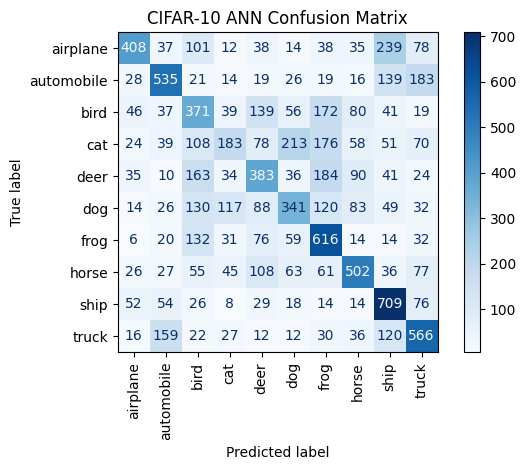

In [43]:
print("\n--- Evaluating ANN Model (CIFAR-10) ---")
loss_ann_cifar, accuracy_ann_cifar = ann_cifar.evaluate(X_test_cifar, y_test_cifar)
print(f"CIFAR-10 ANN Test Accuracy: {accuracy_ann_cifar:.4f}")

# Make predictions
y_pred_ann_cifar_prob = ann_cifar.predict(X_test_cifar)
y_pred_ann_cifar_classes = np.argmax(y_pred_ann_cifar_prob, axis=1)

# Print Classification Report
print("\nClassification Report (CIFAR-10 ANN):")
# Use target_names for readable labels
print(classification_report(y_test_cifar, y_pred_ann_cifar_classes, target_names=classes))

# Display Confusion Matrix
print("\nConfusion Matrix (CIFAR-10 ANN):")
cm_ann_cifar = confusion_matrix(y_test_cifar, y_pred_ann_cifar_classes)
disp_ann_cifar = ConfusionMatrixDisplay(confusion_matrix=cm_ann_cifar, display_labels=classes)
disp_ann_cifar.plot(cmap=plt.cm.Blues, xticks_rotation='vertical') # Rotate labels if needed
plt.title("CIFAR-10 ANN Confusion Matrix")
plt.tight_layout()
plt.show()

In [44]:
print("\n--- Building CNN Model (CIFAR-10) ---")
cnn_cifar = models.Sequential([
    # Conv Layer 1: 32 filters, 3x3 kernel, ReLU activation. Input shape is 32x32x3
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    # Pool Layer 1: Max pooling with 2x2 window
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 2: 64 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    # Pool Layer 2: Max pooling with 2x2 window
    layers.MaxPooling2D((2, 2)),

    # Flatten the feature maps
    layers.Flatten(),

    # Dense Layer: 64 neurons, ReLU activation
    layers.Dense(64, activation='relu'),
    # Output Layer: 10 neurons (for 10 classes), softmax activation
    layers.Dense(10, activation='softmax')
])

# Compile the CNN model
cnn_cifar.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_cifar.summary()

print("\n--- Training CNN Model (CIFAR-10) ---")
# Train for more epochs as CIFAR-10 is more complex than MNIST
history_cnn_cifar = cnn_cifar.fit(X_train_cifar, y_train_cifar, epochs=10, validation_split=0.1)


--- Building CNN Model (CIFAR-10) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Training CNN Model (CIFAR-10) ---
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4414 - loss: 1.5440 - val_accuracy: 0.5496 - val_loss: 1.2692
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5853 - loss: 1.1767 - val_accuracy: 0.6250 - val_loss: 1.0745
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6361 - loss: 1.0436 - val_accuracy: 0.6506 - val_loss: 1.0098
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6657 - loss: 0.9618 - val_accuracy: 0.6716 - val_loss: 0.9538
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6887 - loss: 0.8978 - val_accuracy: 0.6740 - val_loss: 0.9467
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7082 - loss: 0.8445 - val_accuracy: 0.6778 - val_loss: 0.9516
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7245 - loss: 0.7955 - val_accuracy: 0.6796 - val_loss: 0.9583
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/s

In [45]:
print("\n--- Evaluating CNN Model (CIFAR-10) ---")
loss_cnn_cifar, accuracy_cnn_cifar = cnn_cifar.evaluate(X_test_cifar, y_test_cifar)
print(f"CIFAR-10 CNN Test Accuracy: {accuracy_cnn_cifar:.4f}")


--- Evaluating CNN Model (CIFAR-10) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6654 - loss: 1.0401
CIFAR-10 CNN Test Accuracy: 0.6654



--- CIFAR-10 Model Comparison ---
CIFAR-10 ANN Test Accuracy: 0.4614
CIFAR-10 CNN Test Accuracy: 0.6654

The performance gap between ANN and CNN is usually even larger on
more complex datasets like CIFAR-10 compared to MNIST.
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Visualizing CNN Predictions (CIFAR-10 Examples) ---


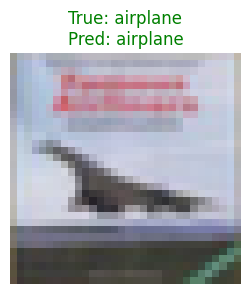

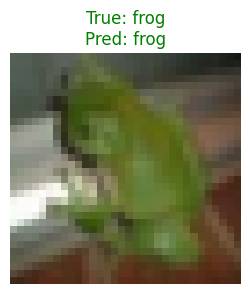

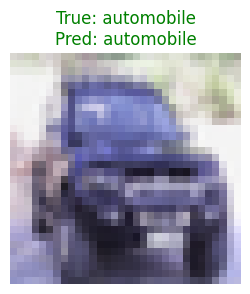


Confusion Matrix (CIFAR-10 CNN):


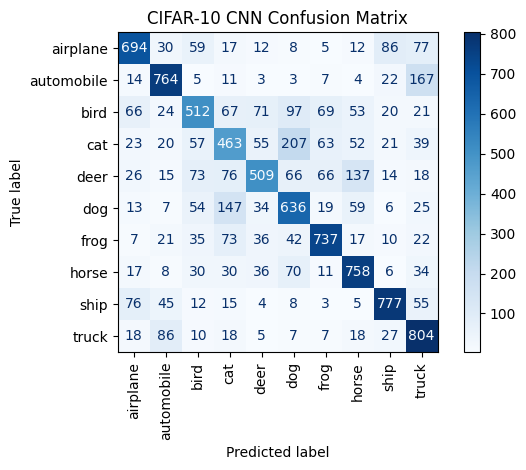

In [46]:
print("\n--- CIFAR-10 Model Comparison ---")
print(f"CIFAR-10 ANN Test Accuracy: {accuracy_ann_cifar:.4f}")
print(f"CIFAR-10 CNN Test Accuracy: {accuracy_cnn_cifar:.4f}")
# Prompt for reflection:
print("\nThe performance gap between ANN and CNN is usually even larger on")
print("more complex datasets like CIFAR-10 compared to MNIST.")

# Make predictions with the CNN
y_pred_cnn_cifar_prob = cnn_cifar.predict(X_test_cifar)
y_pred_cnn_cifar_classes = np.argmax(y_pred_cnn_cifar_prob, axis=1)

# Define the enhanced plotting function (can reuse from Part 1 if in same notebook)
def plot_sample_with_pred_cifar(X, y_true, y_pred_classes, index, class_names):
    plt.figure(figsize=(3, 3))
    # Display color image - ensure pixel values are appropriate (e.g., 0-1 or 0-255)
    # If normalized to 0-1, imshow works fine. If 0-255, use imshow(X[index].astype('uint8'))
    plt.imshow(X[index])
    true_label = y_true[index]
    pred_label = y_pred_classes[index]
    title_str = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    color = "green" if true_label == pred_label else "red"
    plt.title(title_str, color=color)
    plt.axis('off')
    plt.show()


print("\n--- Visualizing CNN Predictions (CIFAR-10 Examples) ---")
# Show prediction for a few test samples
plot_sample_with_pred_cifar(X_test_cifar, y_test_cifar, y_pred_cnn_cifar_classes, 3, classes) # Index 3
plot_sample_with_pred_cifar(X_test_cifar, y_test_cifar, y_pred_cnn_cifar_classes, 7, classes) # Index 7
plot_sample_with_pred_cifar(X_test_cifar, y_test_cifar, y_pred_cnn_cifar_classes, 9, classes) # Index 9


# Display CNN Confusion Matrix
print("\nConfusion Matrix (CIFAR-10 CNN):")
cm_cnn_cifar = confusion_matrix(y_test_cifar, y_pred_cnn_cifar_classes)
disp_cnn_cifar = ConfusionMatrixDisplay(confusion_matrix=cm_cnn_cifar, display_labels=classes)
disp_cnn_cifar.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("CIFAR-10 CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [47]:
# CNN Model for CIFAR-10
cnn_cifar = models.Sequential([
    # Conv Layer 1: 32 filters, 3x3 kernel, ReLU activation. Input shape is 32x32x3
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    # Pool Layer 1: Max pooling with 2x2 window
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 2: 64 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    # Pool Layer 2: Max pooling with 2x2 window
    layers.MaxPooling2D((2, 2)),

    # Flatten the feature maps
    layers.Flatten(),

    # Dense Layer: 64 neurons, ReLU activation
    layers.Dense(64, activation='relu'),
    # Output Layer: 10 neurons (for 10 classes), softmax activation
    layers.Dense(10, activation='softmax')
])

# Compile the CNN model
cnn_cifar.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Training command (context for Q13-15)
# history_cnn_cifar = cnn_cifar.fit(X_train_cifar, y_train_cifar, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
